# Week 12 - Milestone Two week

# 1. Lesson: no lesson this week.  Milestone Two is due!

# 2. Weekly graph question

Suppose you plot the number visitors to a museum over the seven days of a week; then again the following week.  Can you suggest the advantages and disadvantages of the following two ways of presenting the data?

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

Text(0, 0.5, 'Number of visitors')

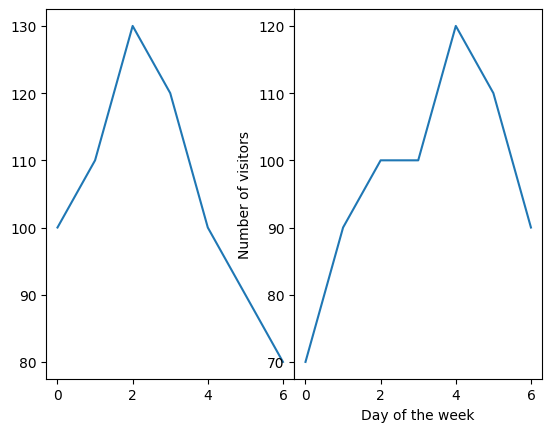

In [2]:
np.random.seed(0)
time_series_0 = np.array([100, 110, 130, 120, 100, 90, 80])
time_series_1 = np.array([70, 90, 100, 100, 120, 110, 90])
fig, axs = plt.subplots(1, 2)
axs[0].plot(time_series_0)
axs[1].plot(time_series_1)
plt.subplots_adjust(wspace = 0)
plt.xlabel("Day of the week")
plt.ylabel("Number of visitors")

Text(0, 0.5, 'Number of visitors')

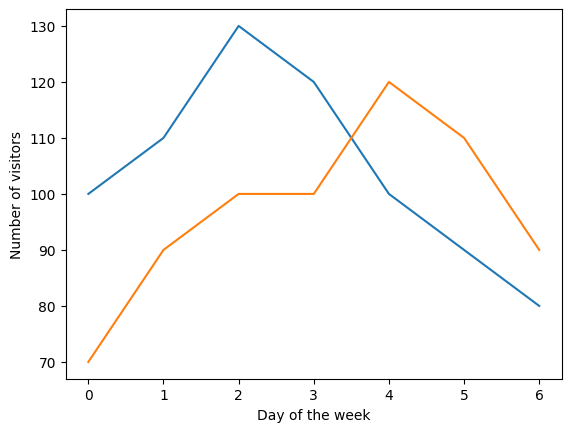

In [3]:
plt.plot(time_series_0)
plt.plot(time_series_1)
plt.xlabel("Day of the week")
plt.ylabel("Number of visitors")

**Presentation 1 — Side-by-Side Separate Plots**

**Advantages**: Each week is presented in its own visual space, making it easy to read and interpret a single week's pattern in isolation without the distraction of the other. This format works well when the goal is to understand the internal shape of each week independently — for example, identifying that Week 1 peaks on Wednesday while Week 2 peaks on Friday. It also avoids visual clutter when the two lines would otherwise heavily overlap.

**Disadvantages**: Comparing the two weeks directly is cognitively demanding because the eye must jump back and forth between two separate panels. Subtle differences in visitor counts on the same day are difficult to judge when the lines are not plotted against the same reference point simultaneously. The shared y-axis is critical here — without enforcing identical y-axis scales across both panels, the comparison becomes misleading.

**Presentation 2 — Overlaid Single Plot**

**Advantages**: Placing both weeks on the same axes makes week-over-week comparison immediate and effortless. The crossing of the two lines is instantly visible — showing that Week 1 starts higher but Week 2 overtakes it by Friday — which would be easy to miss in the side-by-side format. This presentation is far more effective for storytelling when the central message is about the relationship or difference between the two weeks rather than the individual patterns.

**Disadvantages**: When the two lines are close together or cross frequently, the chart can become cluttered and harder to read. With more than two weeks of data, this approach quickly degenerates into the "spaghetti graph" problem described in Storytelling with Data Chapter 7, where too many overlapping lines make it impossible to isolate any single series. Color choice also becomes critical — poor color selection makes the two series indistinguishable.

**Recommendation**
Presentation 2 is the stronger choice for this specific scenario because the central analytical question — how do the two weeks compare day by day — is best answered by direct visual overlay. The side-by-side format should be reserved for cases where each series needs to stand alone, or when the number of series makes overlaying impractical.

# 3. Working on your datasets

This week, you can work on Milestone Two rather than having a particular exercise about working on your datasets

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 187-205 of the Storytelling With Data book as best you can. (Chapter Eight). You do not have to get the exact data values right, just the overall look and feel.

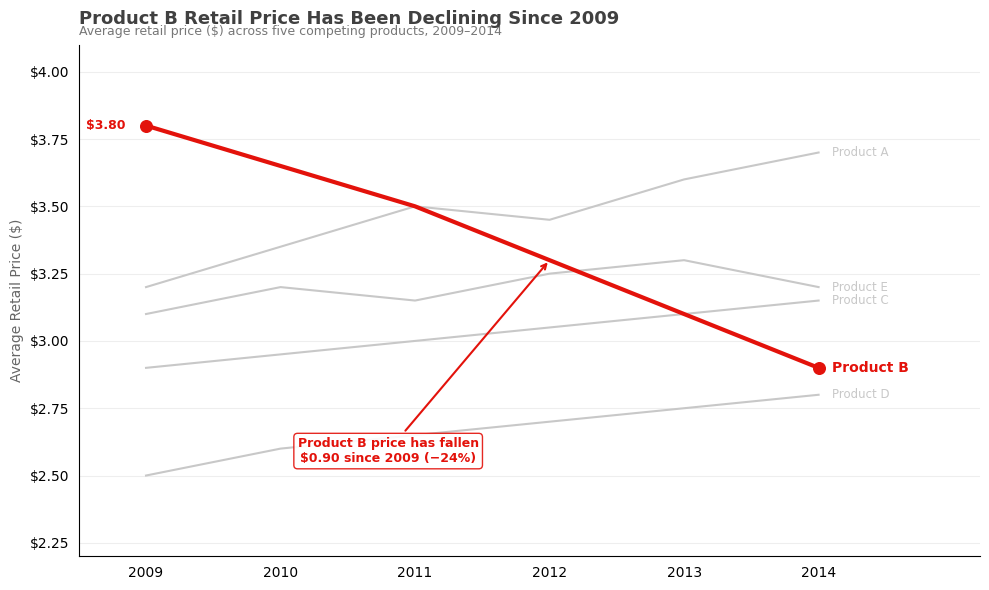

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# SWD Chapter 8 — Final Polished Chart: "Pulling It All Together"
# Average retail price over time — 5 competing products
# Story: Product B is declining and needs attention
# ══════════════════════════════════════════════════════════════════════════════

years = [2009, 2010, 2011, 2012, 2013, 2014]
products = {
    'Product A': [3.20, 3.35, 3.50, 3.45, 3.60, 3.70],
    'Product B': [3.80, 3.65, 3.50, 3.30, 3.10, 2.90],  # story line
    'Product C': [2.90, 2.95, 3.00, 3.05, 3.10, 3.15],
    'Product D': [2.50, 2.60, 2.65, 2.70, 2.75, 2.80],
    'Product E': [3.10, 3.20, 3.15, 3.25, 3.30, 3.20],
}

HIGHLIGHT = 'Product B'
GRAY, ACCENT = '#C8C8C8', '#E3120B'

fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

# Gray context lines
for name, values in products.items():
    if name != HIGHLIGHT:
        ax.plot(years, values, color=GRAY, linewidth=1.5, zorder=1)
        ax.text(2014.1, values[-1], name, fontsize=8.5,
                color=GRAY, va='center', ha='left')

# Red story line
hv = products[HIGHLIGHT]
ax.plot(years, hv, color=ACCENT, linewidth=3.0, zorder=3)
ax.scatter([years[0], years[-1]], [hv[0], hv[-1]],
           color=ACCENT, s=70, zorder=4)
ax.text(2014.1, hv[-1], HIGHLIGHT, fontsize=10,
        color=ACCENT, fontweight='bold', va='center', ha='left')

# Price labels
ax.text(2008.85, hv[0], f'${hv[0]:.2f}',
        fontsize=9, color=ACCENT, fontweight='bold', va='center', ha='right')

# Callout annotation
ax.annotate('Product B price has fallen\n$0.90 since 2009 (−24%)',
            xy=(2012, hv[3]), xytext=(2010.8, 2.55),
            fontsize=9, color=ACCENT, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=ACCENT, lw=1.5),
            ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=ACCENT, alpha=0.9))

# Title states the insight directly
ax.set_title('Product B Retail Price Has Been Declining Since 2009',
             fontsize=13, fontweight='bold', color='#404040',
             loc='left', pad=15)
ax.text(0.0, 1.02,
        'Average retail price ($) across five competing products, 2009–2014',
        transform=ax.transAxes, fontsize=9, color='#777777')

# Axis & cleanup
ax.set_ylabel('Average Retail Price ($)', fontsize=10, color='#666666')
ax.set_xlim(2008.5, 2015.2)
ax.set_ylim(2.2, 4.1)
ax.set_xticks(years)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.2f}'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(left=False, bottom=False)
ax.yaxis.grid(True, color='#EEEEEE', linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()